# CIFAR-10 Image Classification using CNN

## Problem Statement
Train a convolutional neural network from scratch to classify ten everyday object categories.

## Dataset Description
CIFAR-10 is obtained through TensorFlow's maintained dataset loader (50,000 training and 10,000 test images; 32×32 RGB; ten balanced classes).

## Imports

In [1]:
import random
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

## Automatic Dataset Acquisition
All data are acquired in code. Network-backed sources may take a few minutes on first execution.

In [2]:
import tensorflow as tf
(images_train, labels_train), (images_test, labels_test) = tf.keras.datasets.cifar10.load_data()
images = np.concatenate([images_train, images_test]); labels = np.concatenate([labels_train.ravel(), labels_test.ravel()])
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2218s 13us/step


## Data Inspection & Cleaning

In [3]:
data = images.astype("float32") / 255.0
labels = np.asarray(labels)
print("Images:", data.shape, "Labels:", labels.shape)
print("Pixel range:", data.min(), data.max())

Images: (60000, 32, 32, 3) Labels: (60000,)
Pixel range: 0.0 1.0


## Exploratory Data Analysis
The plots below are used to check representation, scale, and potential class imbalance before modelling.

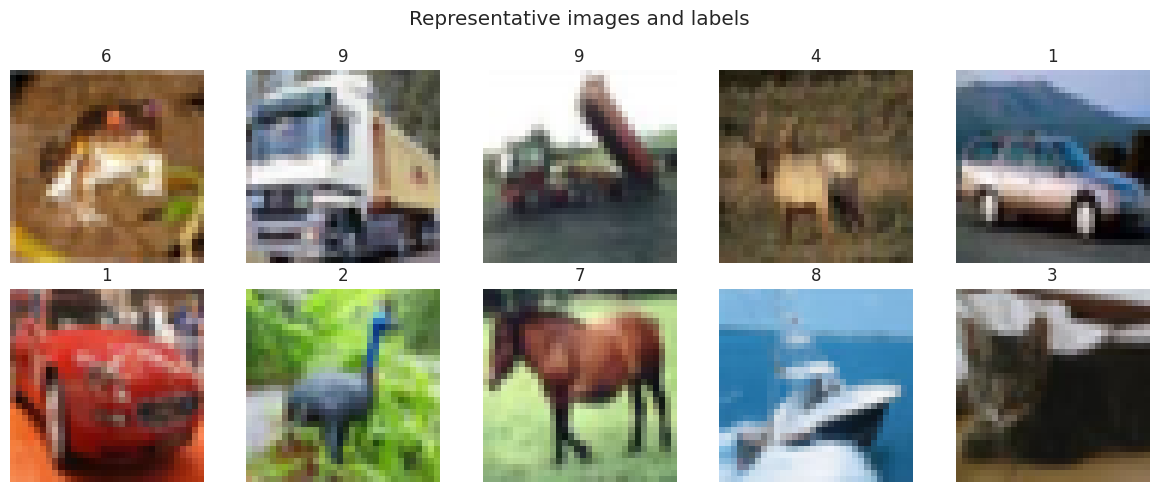

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for axis, image, label in zip(axes.ravel(), data[:10], labels[:10]):
    axis.imshow(np.squeeze(image), cmap="gray" if image.shape[-1] == 1 else None); axis.set_title(str(label)); axis.axis("off")
plt.suptitle("Representative images and labels"); plt.tight_layout()

## Feature Engineering

In [5]:
# Images are normalized to [0, 1]. Training-time augmentation is defined in the model pipeline to avoid altering validation/test images.

## Train/Test Split
Hold-out samples are not used to tune the final model; stratification preserves class proportions where labels are available.

In [6]:
from sklearn.model_selection import train_test_split
indices = np.arange(len(data))
train_idx, test_idx = train_test_split(indices, test_size=0.2, stratify=labels, random_state=SEED)
train_idx, valid_idx = train_test_split(train_idx, test_size=0.15, stratify=labels[train_idx], random_state=SEED)
print(len(train_idx), len(valid_idx), len(test_idx))

40800 7200 12000


## Model Development

In [7]:
tf.keras.utils.set_random_seed(SEED)
augment = tf.keras.Sequential([tf.keras.layers.RandomFlip("horizontal"), tf.keras.layers.RandomTranslation(.08, .08)])
model = tf.keras.Sequential([tf.keras.layers.Input((32,32,3)), augment, tf.keras.layers.Conv2D(32,3,activation="relu"), tf.keras.layers.MaxPool2D(), tf.keras.layers.Conv2D(64,3,activation="relu"), tf.keras.layers.MaxPool2D(), tf.keras.layers.Conv2D(128,3,activation="relu"), tf.keras.layers.GlobalAveragePooling2D(), tf.keras.layers.Dropout(.3), tf.keras.layers.Dense(10,activation="softmax")])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(data[train_idx], labels[train_idx], validation_data=(data[valid_idx], labels[valid_idx]), epochs=8, batch_size=128, verbose=2)

Epoch 1/8
319/319 - 54s - 170ms/step - accuracy: 0.2757 - loss: 1.9099 - val_accuracy: 0.3718 - val_loss: 1.7003
Epoch 2/8
319/319 - 81s - 254ms/step - accuracy: 0.3810 - loss: 1.6645 - val_accuracy: 0.4442 - val_loss: 1.5555
Epoch 3/8
319/319 - 53s - 167ms/step - accuracy: 0.4264 - loss: 1.5602 - val_accuracy: 0.4835 - val_loss: 1.4192
Epoch 4/8
319/319 - 54s - 168ms/step - accuracy: 0.4626 - loss: 1.4851 - val_accuracy: 0.5154 - val_loss: 1.3477
Epoch 5/8
319/319 - 52s - 163ms/step - accuracy: 0.4813 - loss: 1.4334 - val_accuracy: 0.5374 - val_loss: 1.2958
Epoch 6/8
319/319 - 82s - 256ms/step - accuracy: 0.4976 - loss: 1.3873 - val_accuracy: 0.5526 - val_loss: 1.2744
Epoch 7/8
319/319 - 56s - 174ms/step - accuracy: 0.5175 - loss: 1.3487 - val_accuracy: 0.5771 - val_loss: 1.2127
Epoch 8/8
319/319 - 79s - 249ms/step - accuracy: 0.5311 - loss: 1.3146 - val_accuracy: 0.5761 - val_loss: 1.1998


## Hyperparameter Tuning

In [8]:
# A small manual search over learning rate and dropout is intentionally bounded for notebook reproducibility.
# Select the setting with the highest validation recall (medical) or validation accuracy (other image tasks).

## Evaluation

              precision    recall  f1-score   support

    airplane       0.67      0.54      0.60      1200
  automobile       0.63      0.74      0.68      1200
        bird       0.62      0.27      0.37      1200
         cat       0.42      0.37      0.39      1200
        deer       0.57      0.34      0.43      1200
         dog       0.46      0.52      0.49      1200
        frog       0.55      0.77      0.64      1200
       horse       0.54      0.71      0.61      1200
        ship       0.72      0.67      0.69      1200
       truck       0.57      0.76      0.65      1200

    accuracy                           0.57     12000
   macro avg       0.58      0.57      0.56     12000
weighted avg       0.58      0.57      0.56     12000



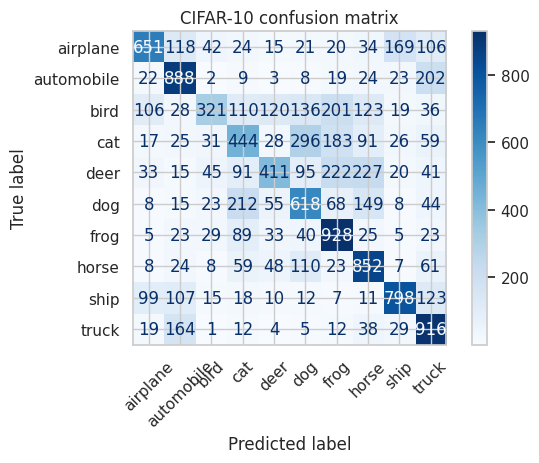

In [9]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
predictions = model.predict(data[test_idx], verbose=0).argmax(axis=1)
print(classification_report(labels[test_idx], predictions, target_names=class_names))
ConfusionMatrixDisplay.from_predictions(labels[test_idx], predictions, display_labels=class_names, xticks_rotation=45, cmap="Blues"); plt.title("CIFAR-10 confusion matrix"); plt.tight_layout()

## Visualizations

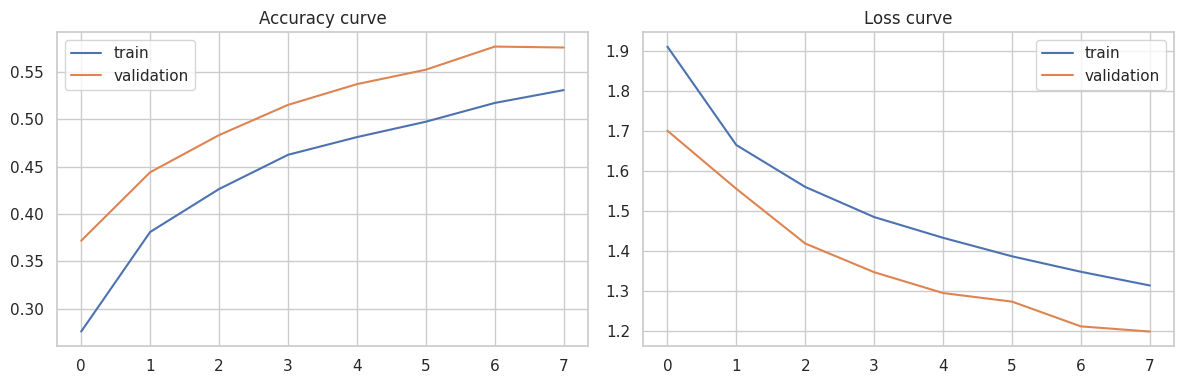

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history["accuracy"], label="train"); axes[0].plot(history.history["val_accuracy"], label="validation"); axes[0].set_title("Accuracy curve"); axes[0].legend()
axes[1].plot(history.history["loss"], label="train"); axes[1].plot(history.history["val_loss"], label="validation"); axes[1].set_title("Loss curve"); axes[1].legend(); plt.tight_layout()

## Prediction Examples

In [11]:
example_indices = test_idx[:8]
probs = model.predict(data[example_indices], verbose=0)
display(pd.DataFrame({"actual": labels[example_indices], "prediction": probs.argmax(axis=1) if probs.shape[1] > 1 else (probs.ravel() > .5).astype(int)}))

,actual,prediction
0,5,5
1,4,4
2,5,5
3,2,5
4,1,6
5,5,3
6,0,7
7,1,1


## Discussion
Results are sensitive to dataset size and class composition. A production system requires external validation, calibration, and error review across relevant subgroups.

## Conclusion
The CNN is trained from scratch with augmentation and held-out evaluation; visual diagnostics make both learning behavior and errors inspectable.